<a href="https://colab.research.google.com/github/s-bishal/ML-Lab/blob/main/CNN_Leaf_Disease_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [ ]:
import pathlib
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import seaborn as sns
import pandas as pd

from pathlib import Path

from tensorflow.keras import layers,models
from tensorflow.keras.models import Sequential
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [ ]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


Download Dataset

In [ ]:
path = kagglehub.dataset_download("asheniranga/leaf-disease-dataset-combination")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'leaf-disease-dataset-combination' dataset.
Path to dataset files: /kaggle/input/leaf-disease-dataset-combination


Copy Dataset

In [ ]:
import shutil
src = "/kaggle/input/leaf-disease-dataset-combination"
dst = "/content"
shutil.copytree(src, dst, dirs_exist_ok=True)

'/content'

Dataset Folder Structure

In [ ]:
testcount = 0
traincount = 0
validationcount = 0
count = 0

dataset_path = Path("/content/image data")
image_extensions = {".jpg", ".jpeg"}

for type_dir in dataset_path.iterdir():
      if type_dir.is_dir():
            print(f"Type: {type_dir.name}")

            for plant in type_dir.iterdir():
                if plant.is_dir():
                    print(f"Plant: {plant.name}")

                    for disease in plant.iterdir():
                        if disease.is_dir():
                            print(f"  Disease: {disease.name}")

                            for image in disease.rglob("*"):
                              if image.is_file() and image.suffix.lower() in image_extensions:
                              # print(f"    Image: {img.name}")
                                count+=1
                                if type_dir.name == "test":
                                    testcount += 1
                                elif type_dir.name == "train":
                                    traincount += 1
                                elif type_dir.name == "validation":
                                    validationcount += 1

print(f"Total train images: {traincount}")
print(f"Total test images: {testcount}")
print(f"Total validation images: {validationcount}")
print(f"Total images: {count}")


Type: train
Plant: orange
  Disease: haunglongbing (citrus greening)
Plant: squash
  Disease: powdery mildew
Plant: strawberry
  Disease: leaf scorch
  Disease: healthy
Plant: tomato
  Disease: spider mites two-spotted spider mite
  Disease: septoria leaf spot
  Disease: leaf mold
  Disease: tomato mosaic virus
  Disease: late blight
  Disease: tomato yellow leaf curl virus
  Disease: bacterial spot
  Disease: early blight
  Disease: target spot
  Disease: healthy
Plant: apple
  Disease: apple scab
  Disease: black rot
  Disease: cedar apple rust
  Disease: healthy
Plant: pepper, bell
  Disease: bacterial spot
  Disease: healthy
Plant: Rice
  Disease: Hispa
  Disease: BrownSpot
  Disease: LeafBlast
  Disease: Healthy
Plant: grape
  Disease: black rot
  Disease: leaf blight (isariopsis leaf spot)
  Disease: healthy
  Disease: esca (black measles)
Plant: corn (maize)
  Disease: cercospora leaf spot gray leaf spot
  Disease: common rust
  Disease: northern leaf blight
  Disease: healthy
P

Flatten Dataset

In [ ]:
import shutil
# Original dataset
dataset = Path("/content/image data")

# New dataset
fixed_dataset = Path("/content/image data fixed")


for split in ["train", "validation", "test"]:

    source = dataset / split
    destination = fixed_dataset / split

    for plant in source.iterdir():

        if not plant.is_dir():
            continue

        for disease in plant.iterdir():

            if not disease.is_dir():
                continue

            # Create class name
            class_name = f"{plant.name}_{disease.name}"

            class_folder = destination / class_name
            class_folder.mkdir(parents=True, exist_ok=True)

            for image in disease.iterdir():

                if image.is_file() and image.suffix.lower() in image_extensions:

                    shutil.copy2(
                        image,
                        class_folder / image.name
                    )

print("Dataset prepared successfully!")

Dataset prepared successfully!


Dataset Directries

In [ ]:
train_dir = fixed_dataset / "train"
validation_dir = fixed_dataset / "validation"
test_dir = fixed_dataset / "test"

print(train_dir)
print(validation_dir)
print(test_dir)

/content/image data fixed/train
/content/image data fixed/validation
/content/image data fixed/test


Hyperparameters

In [ ]:
IMG_HEIGHT = 128
IMG_WIDTH = 128

BATCH_SIZE = 16

EPOCHS = 20

Loading Image Data Sets

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    shuffle=True
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    shuffle=False
)

Found 38104 files belonging to 44 classes.
Found 9458 files belonging to 44 classes.
Found 5741 files belonging to 44 classes.


Display Classes

In [ ]:
class_names = train_ds.class_names

print(class_names)

num_classes = len(class_names)

print(num_classes)

['Cassava_Bacterial Blight (CBB)', 'Cassava_Brown Streak Disease (CBSD)', 'Cassava_Green Mottle (CGM)', 'Cassava_Healthy', 'Cassava_Mosaic Disease (CMD)', 'Rice_BrownSpot', 'Rice_Healthy', 'Rice_Hispa', 'Rice_LeafBlast', 'apple_apple scab', 'apple_black rot', 'apple_cedar apple rust', 'apple_healthy', 'cherry (including sour)_healthy', 'cherry (including sour)_powdery mildew', 'corn (maize)_cercospora leaf spot gray leaf spot', 'corn (maize)_common rust', 'corn (maize)_healthy', 'corn (maize)_northern leaf blight', 'grape_black rot', 'grape_esca (black measles)', 'grape_healthy', 'grape_leaf blight (isariopsis leaf spot)', 'orange_haunglongbing (citrus greening)', 'peach_bacterial spot', 'peach_healthy', 'pepper, bell_bacterial spot', 'pepper, bell_healthy', 'potato_early blight', 'potato_healthy', 'potato_late blight', 'squash_powdery mildew', 'strawberry_healthy', 'strawberry_leaf scorch', 'tomato_bacterial spot', 'tomato_early blight', 'tomato_healthy', 'tomato_late blight', 'tomato

In [ ]:
print("Number of classes:", len(class_names))

for i, name in enumerate(class_names):
    print(i, name)

Number of classes: 44
0 Cassava_Bacterial Blight (CBB)
1 Cassava_Brown Streak Disease (CBSD)
2 Cassava_Green Mottle (CGM)
3 Cassava_Healthy
4 Cassava_Mosaic Disease (CMD)
5 Rice_BrownSpot
6 Rice_Healthy
7 Rice_Hispa
8 Rice_LeafBlast
9 apple_apple scab
10 apple_black rot
11 apple_cedar apple rust
12 apple_healthy
13 cherry (including sour)_healthy
14 cherry (including sour)_powdery mildew
15 corn (maize)_cercospora leaf spot gray leaf spot
16 corn (maize)_common rust
17 corn (maize)_healthy
18 corn (maize)_northern leaf blight
19 grape_black rot
20 grape_esca (black measles)
21 grape_healthy
22 grape_leaf blight (isariopsis leaf spot)
23 orange_haunglongbing (citrus greening)
24 peach_bacterial spot
25 peach_healthy
26 pepper, bell_bacterial spot
27 pepper, bell_healthy
28 potato_early blight
29 potato_healthy
30 potato_late blight
31 squash_powdery mildew
32 strawberry_healthy
33 strawberry_leaf scorch
34 tomato_bacterial spot
35 tomato_early blight
36 tomato_healthy
37 tomato_late bli

Check Images

In [ ]:
for images, labels in train_ds.take(1):

    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)

Image shape: (16, 128, 128, 1)
Label shape: (16,)


Display Sample Images

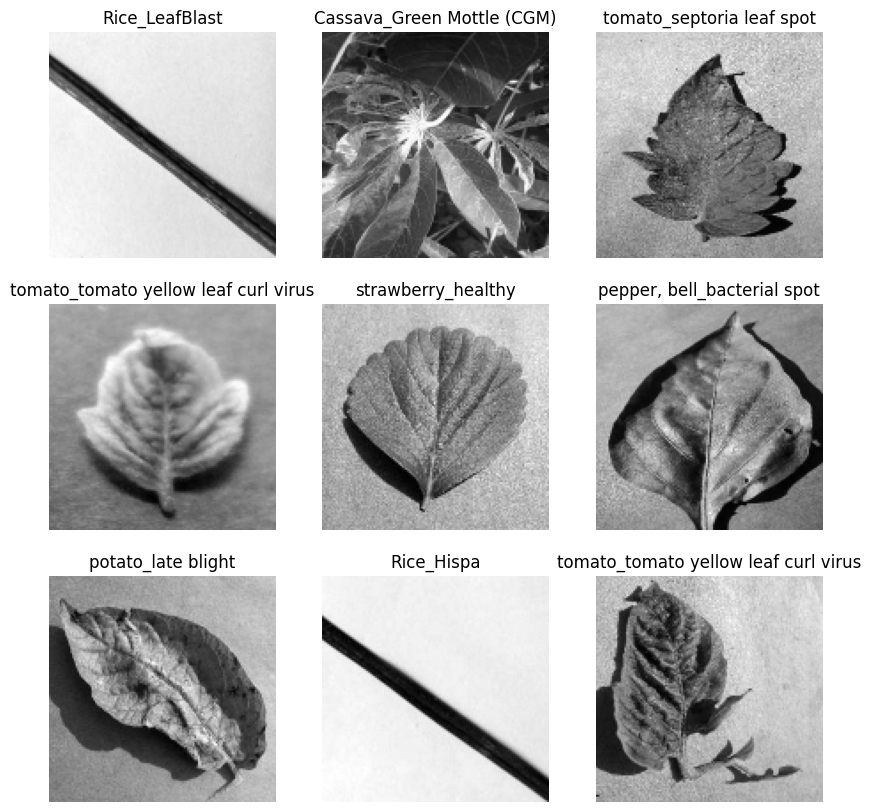

In [ ]:
plt.figure(figsize=(10,10))

for images,labels in train_ds.take(1):

    for i in range(min(9, images.shape[0])):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"), cmap="gray")

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

Autotune (improve performance/optimization pipeline)

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)

validation_ds = validation_ds.cache().prefetch(AUTOTUNE)

test_ds = test_ds.cache().prefetch(AUTOTUNE)

CNN (17 Layers)

In [ ]:
model = Sequential([

    # Input
    layers.Input(shape=(128, 128, 1)),

    # 1. Rescaling
    layers.Rescaling(1.0 / 255),

    # 2. Conv2D - 32
    layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    # 3. Batch Normalization
    layers.BatchNormalization(),

    # 4. Max Pooling
    layers.MaxPooling2D((2, 2)),

    # 5. Conv2D - 64
    layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    # 6. Batch Normalization
    layers.BatchNormalization(),

    # 7. Max Pooling
    layers.MaxPooling2D((2, 2)),

    # 8. Conv2D - 128
    layers.Conv2D(
        128,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    # 9. Batch Normalization
    layers.BatchNormalization(),

    # 10. Max Pooling
    layers.MaxPooling2D((2, 2)),

    # 11. Conv2D - 256
    layers.Conv2D(
        256,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    # 12. Batch Normalization
    layers.BatchNormalization(),

    # 13. Max Pooling
    layers.MaxPooling2D((2, 2)),

    # 14. Flatten
    layers.Flatten(),

    # 15. Dense
    layers.Dense(
        256,
        activation="relu"
    ),

    # 16. Dropout
    layers.Dropout(0.5),

    # 17. Output
    layers.Dense(
        num_classes,
        activation="softmax"
    )
])



Model Summary

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 44)             │        11,308 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,595,628 (17.53 MB)

 Trainable params: 4,594,668 (17.53 MB)

 Non-trainable params: 960 (3.75 KB)

Compile Model

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Create Callabcks

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    save_best_only=True,
    monitor="val_accuracy"
)

Train CNN

In [ ]:
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS,
    callbacks=[early_stop,checkpoint]
)

Epoch 1/20
2382/2382 ━━━━━━━━━━━━━━━━━━━━ 69s 23ms/step - accuracy: 0.1616 - loss: 3.3484 - val_accuracy: 0.2296 - val_loss: 2.7458
Epoch 2/20
2382/2382 ━━━━━━━━━━━━━━━━━━━━ 35s 15ms/step - accuracy: 0.2420 - loss: 2.8643 - val_accuracy: 0.3563 - val_loss: 2.3271
Epoch 3/20
2382/2382 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - accuracy: 0.3115 - loss: 2.4989 - val_accuracy: 0.2724 - val_loss: 2.7454
Epoch 4/20
2382/2382 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - accuracy: 0.3683 - loss: 2.2140 - val_accuracy: 0.5188 - val_loss: 1.7015
Epoch 5/20
2382/2382 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - accuracy: 0.4032 - loss: 2.0104 - val_accuracy: 0.4794 - val_loss: 2.3562
Epoch 6/20
2382/2382 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - accuracy: 0.4521 - loss: 1.7876 - val_accuracy: 0.6052 - val_loss: 1.3437
Epoch 7/20
2382/2382 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - accuracy: 0.5063 - loss: 1.5935 - val_accuracy: 0.5978 - val_loss: 1.8311
Epoch 8/20
2382/2382 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - accuracy: 0.5621 -

Accuracy Curve

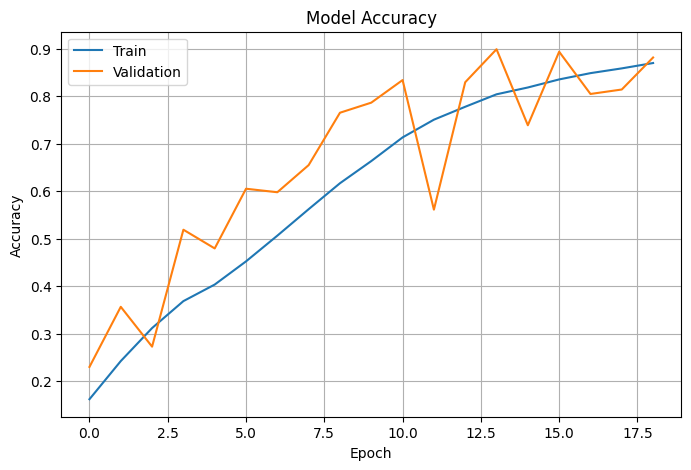

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.grid(True)

plt.show()

Plot Loss Curve

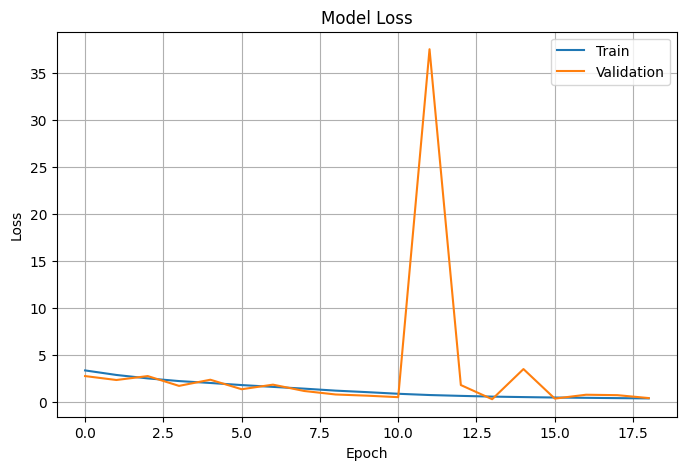

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.grid(True)

plt.show()

Evaluate on Test Set

In [ ]:
test_loss,test_accuracy=model.evaluate(test_ds)

print(f"Test Loss: {test_loss}")

print(f"Test Accuracy: {test_accuracy}")

359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8474 - loss: 0.3953
Test Loss: 0.3952988386154175
Test Accuracy: 0.8474133610725403


Training and Valiation Accuracy

In [ ]:
print("Final training accuracy:",
      history.history["accuracy"][-1])

print("Final validation accuracy:",
      history.history["val_accuracy"][-1])

print("Final training loss:",
      history.history["loss"][-1])

print("Final validation loss:",
      history.history["val_loss"][-1])

Final training accuracy: 0.8701448440551758
Final validation accuracy: 0.881793200969696
Final training loss: 0.36703091859817505
Final validation loss: 0.4025970995426178


Save Model

In [ ]:
model.save("plant_disease_cnn.keras")

Confusion Matrix

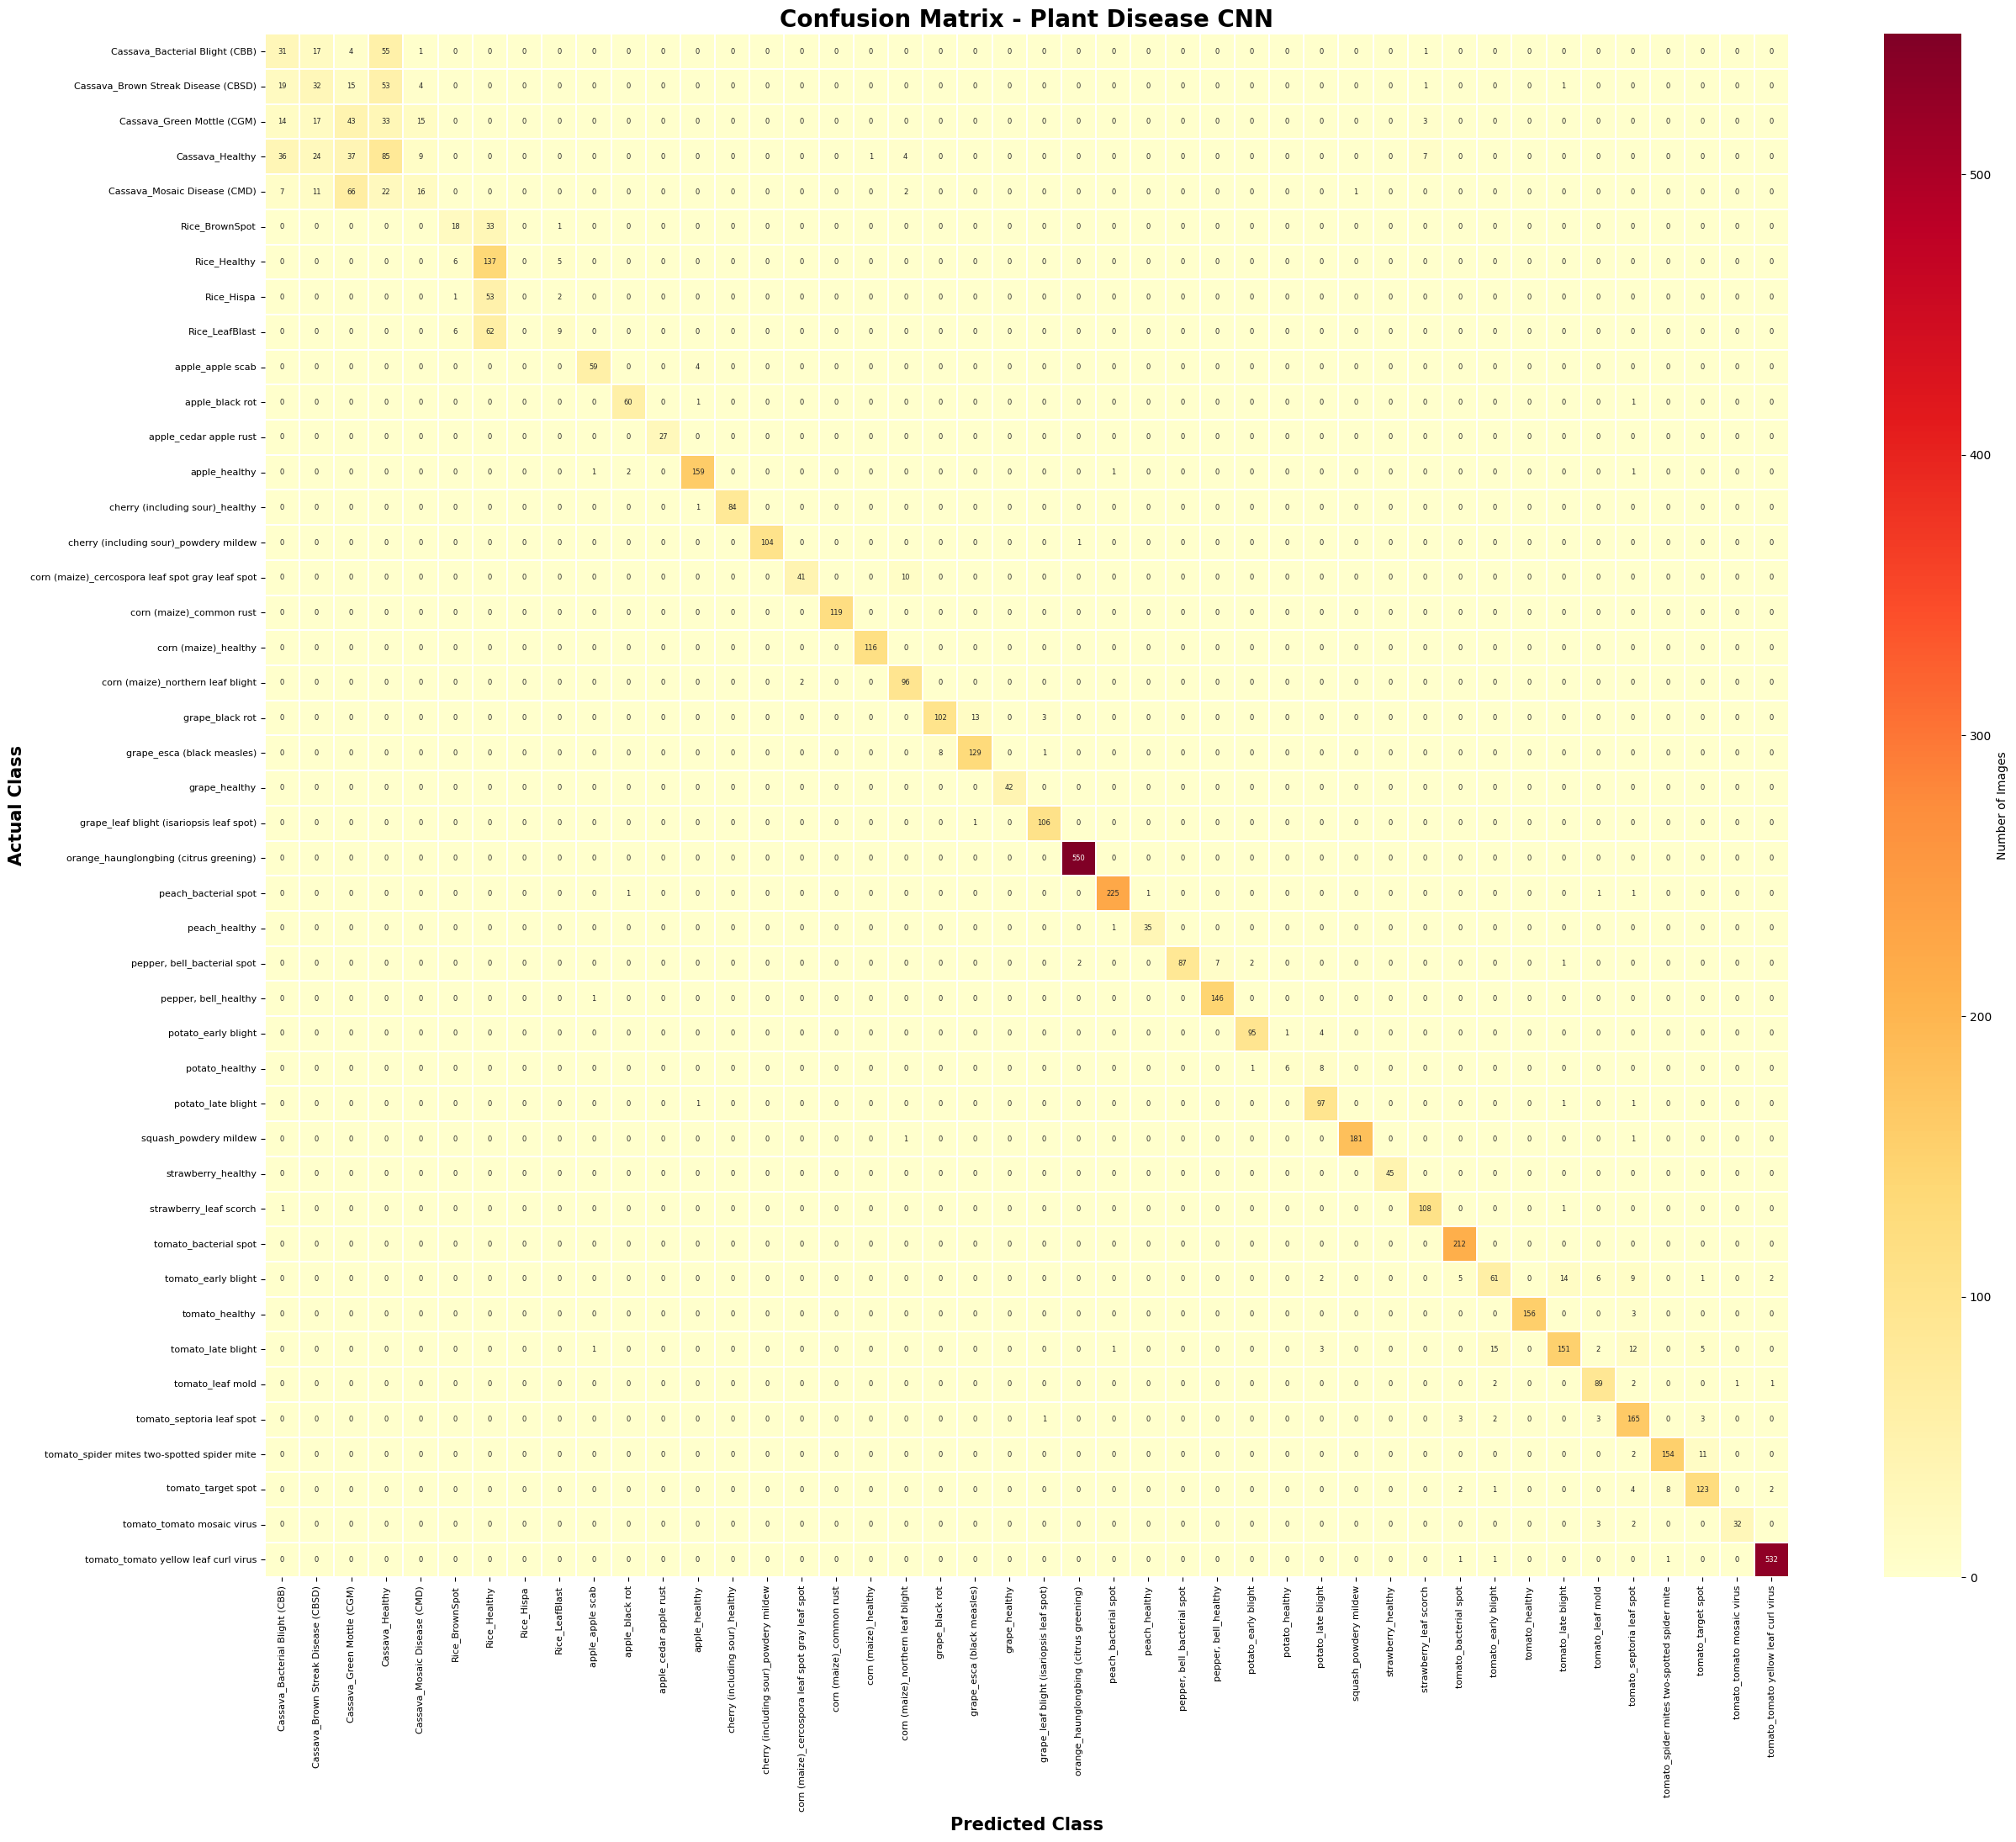

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Create confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(len(class_names))
)

# Plot
plt.figure(figsize=(26, 22))

sns.heatmap(
    cm,
    cmap="YlOrRd",          # same colour as normalized CM
    xticklabels=class_names,
    yticklabels=class_names,
    annot=True,
    fmt="d",
    annot_kws={"fontsize": 6},
    linewidths=0.3,
    linecolor="white",
    cbar_kws={
        "label": "Number of Images"
    }
)

plt.xlabel(
    "Predicted Class",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel(
    "Actual Class",
    fontsize=15,
    fontweight="bold"
)

plt.title(
    "Confusion Matrix - Plant Disease CNN",
    fontsize=20,
    fontweight="bold"
)

plt.xticks(
    rotation=90,
    fontsize=8
)

plt.yticks(
    rotation=0,
    fontsize=8
)

plt.tight_layout()
plt.show()

Normalized CM

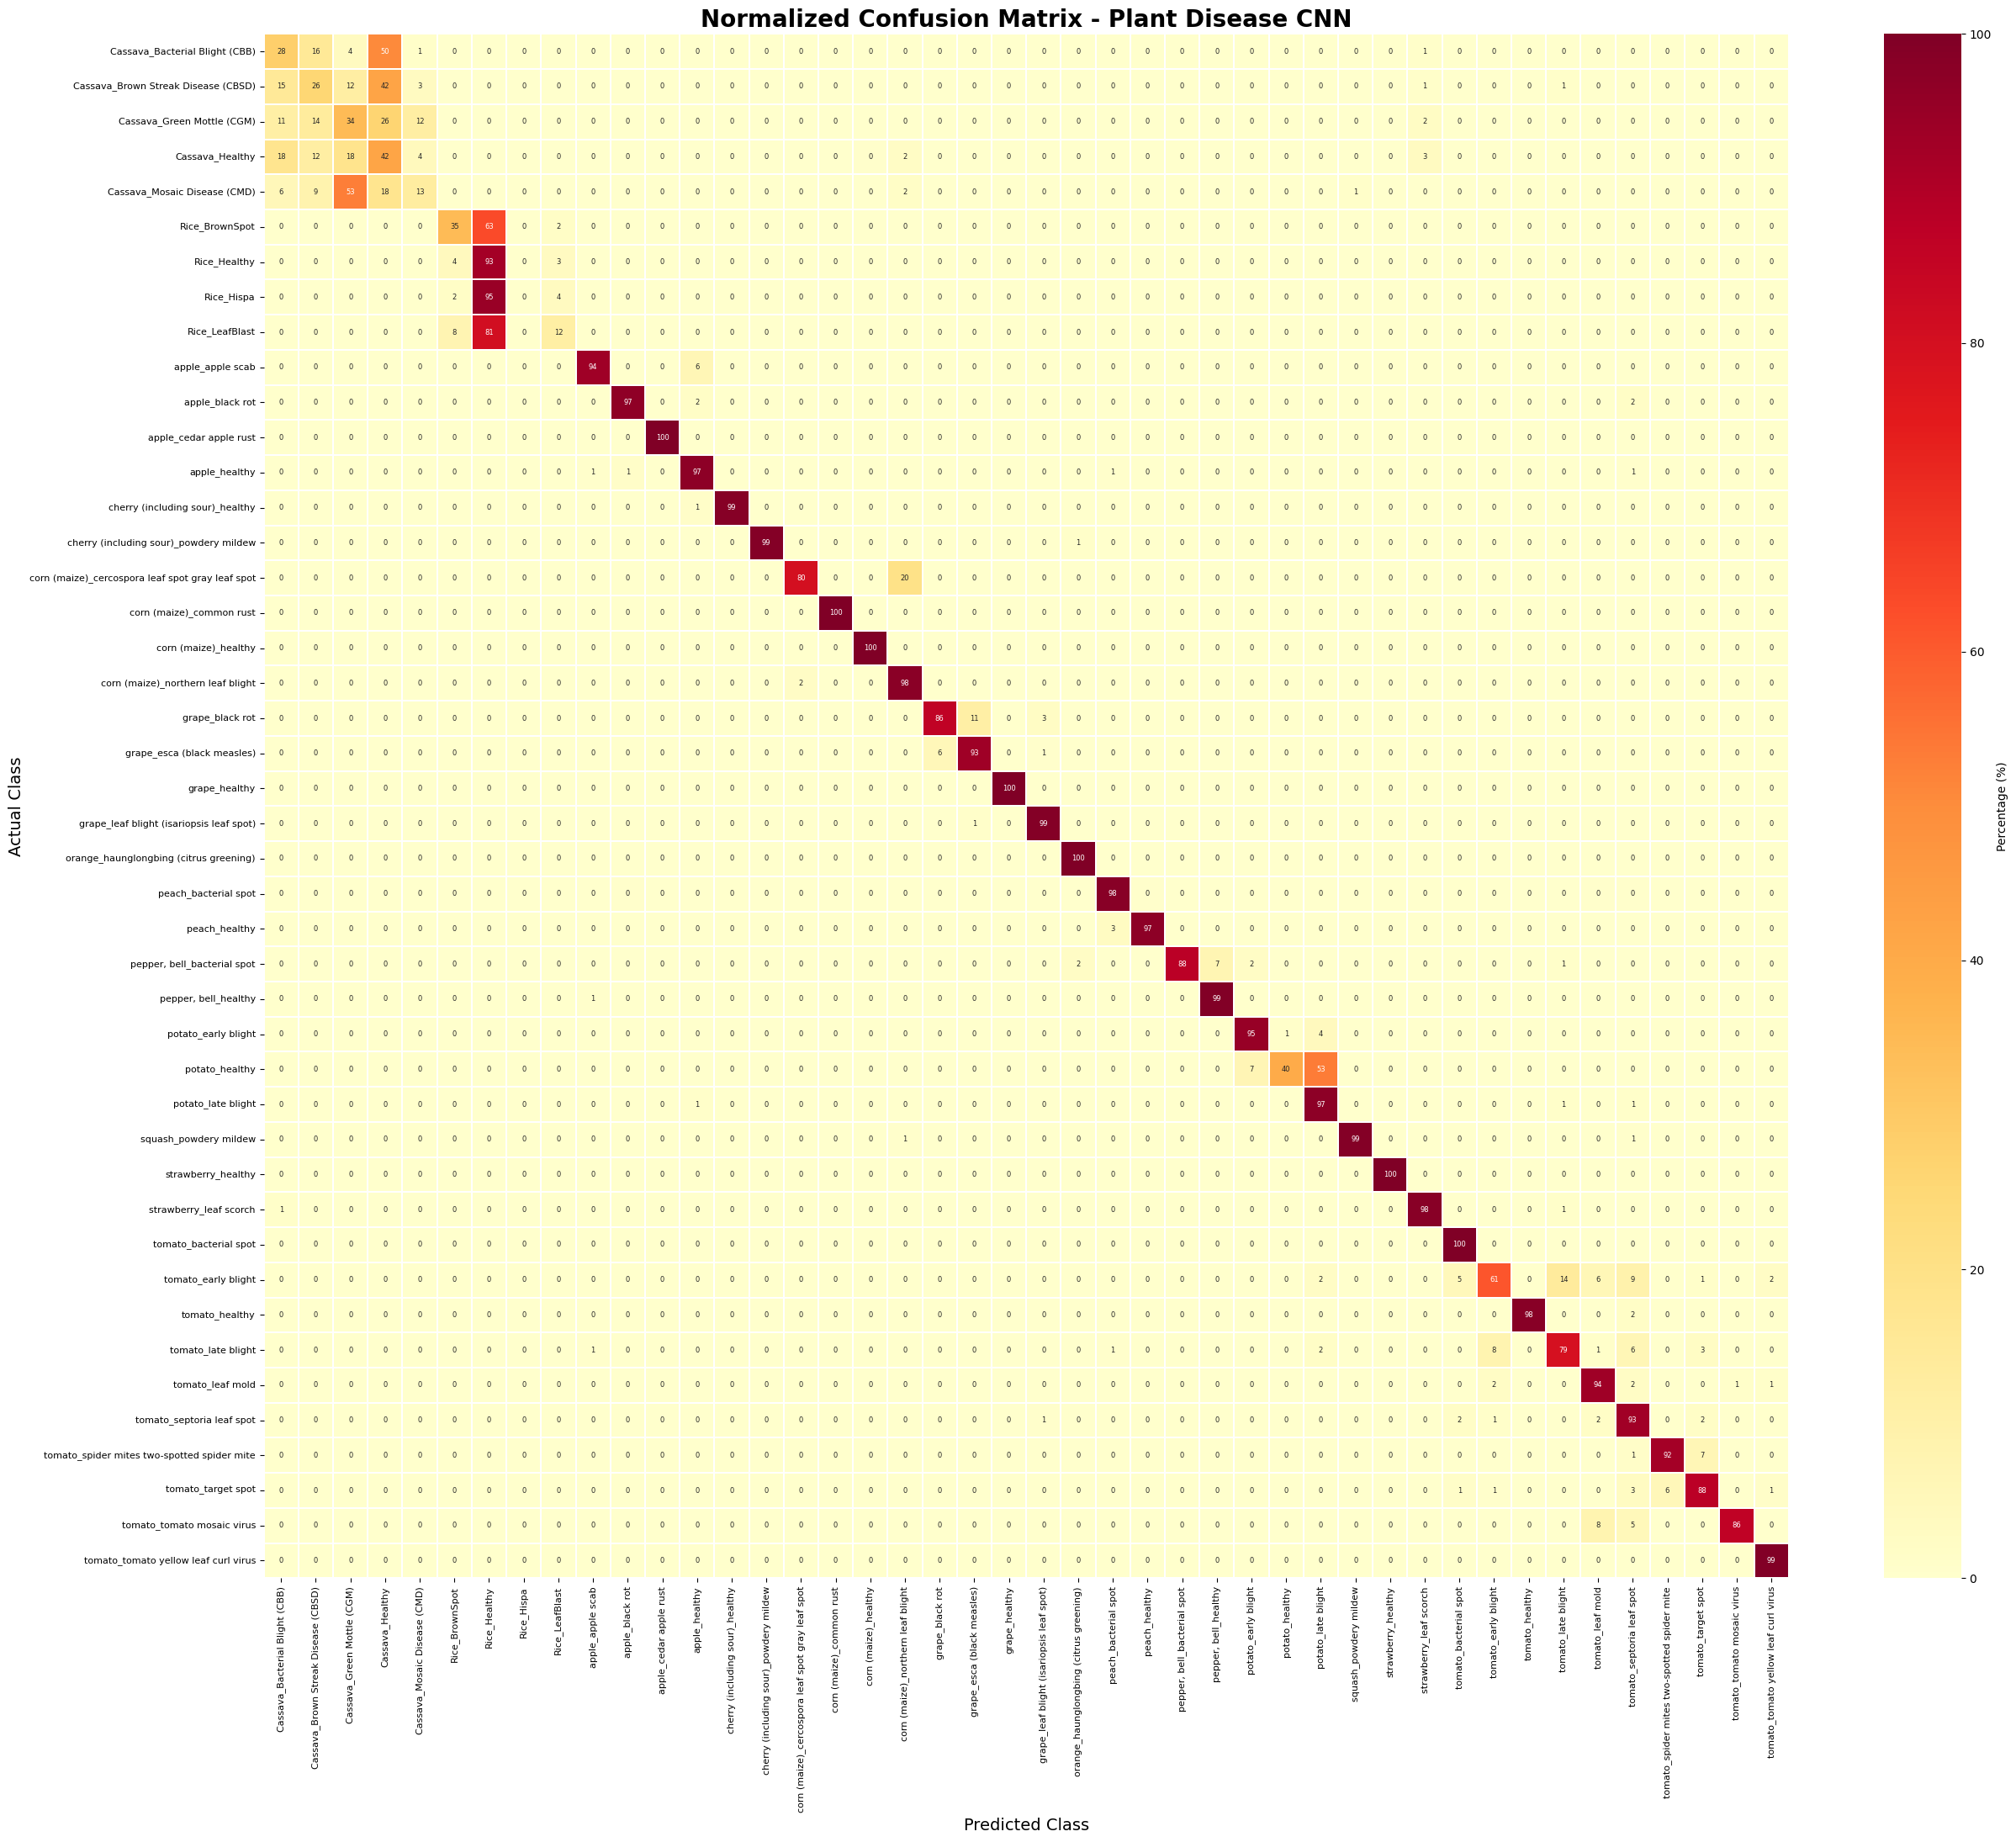

In [ ]:
cm_normalized = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(len(class_names)),
    normalize="true"
)


cm_percent = cm_normalized * 100

plt.figure(figsize=(26, 22))

sns.heatmap(
    cm_percent,
    cmap="YlOrRd",          # clear: light = low, dark red = high
    vmin=0,
    vmax=100,
    xticklabels=class_names,
    yticklabels=class_names,
    annot=True,             # show percentage
    fmt=".0f",
    annot_kws={"fontsize": 6},
    linewidths=0.3,
    linecolor="white",
    cbar_kws={
        "label": "Percentage (%)"
    }
)

plt.xlabel("Predicted Class", fontsize=14)
plt.ylabel("Actual Class", fontsize=14)

plt.title(
    "Normalized Confusion Matrix - Plant Disease CNN",
    fontsize=20,
    fontweight="bold"
)

plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

Classwise Evaluation Matrices

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Accuracy for each class
class_accuracy = {}

for i, class_name in enumerate(class_names):
    mask = (y_true == i)

    if np.sum(mask) > 0:
        class_accuracy[class_name] = accuracy_score(
            y_true[mask],
            y_pred[mask]
        )
    else:
        class_accuracy[class_name] = 0


# Precision
precision = precision_score(
    y_true,
    y_pred,
    average=None,
    labels=np.arange(len(class_names)),
    zero_division=0
)

# Recall
recall = recall_score(
    y_true,
    y_pred,
    average=None,
    labels=np.arange(len(class_names)),
    zero_division=0
)

# F1-score
f1 = f1_score(
    y_true,
    y_pred,
    average=None,
    labels=np.arange(len(class_names)),
    zero_division=0
)


# Create table
evaluation_table = pd.DataFrame({
    "Class": class_names,
    "Accuracy": [
        class_accuracy[name] for name in class_names
    ],
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
})

# Convert to percentage
evaluation_table[
    ["Accuracy", "Precision", "Recall", "F1-score"]
] *= 100

# Round
evaluation_table[
    ["Accuracy", "Precision", "Recall", "F1-score"]
] = evaluation_table[
    ["Accuracy", "Precision", "Recall", "F1-score"]
].round(2)

display(evaluation_table)

,Class,Accuracy,Precision,Recall,F1-score
0,Cassava_Bacterial Blight (CBB),28.44,28.70,28.44,28.57
1,Cassava_Brown Streak Disease (CBSD),25.60,31.68,25.60,28.32
2,Cassava_Green Mottle (CGM),34.40,26.06,34.40,29.66
3,Cassava_Healthy,41.87,34.27,41.87,37.69
4,Cassava_Mosaic Disease (CMD),12.80,35.56,12.80,18.82
5,Rice_BrownSpot,34.62,58.06,34.62,43.37
6,Rice_Healthy,92.57,48.07,92.57,63.28
7,Rice_Hispa,0.00,0.00,0.00,0.00
8,Rice_LeafBlast,11.69,52.94,11.69,19.15
9,apple_apple scab,93.65,95.16,93.65,94.40


Overall Matrices

In [ ]:
overall_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Value (%)": [
        accuracy_score(y_true, y_pred) * 100,
        precision_score(
            y_true, y_pred,
            average="weighted",
            zero_division=0
        ) * 100,
        recall_score(
            y_true, y_pred,
            average="weighted",
            zero_division=0
        ) * 100,
        f1_score(
            y_true, y_pred,
            average="weighted",
            zero_division=0
        ) * 100
    ]
})

overall_metrics["Value (%)"] = overall_metrics["Value (%)"].round(2)

display(overall_metrics)

NameError: name 'pd' is not defined

Download Model

In [ ]:
import os
import json
from google.colab import files



print(os.path.exists("plant_disease_cnn.keras"))
print(os.path.abspath("plant_disease_cnn.keras"))

files.download("plant_disease_cnn.keras")

with open("class_names.json", "w") as f:
    json.dump(class_names, f)


files.download("class_names.json")

False
/content/plant_disease_cnn.keras


FileNotFoundError: Cannot find file: plant_disease_cnn.keras

In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file == "plant_disease_cnn.keras":
            print("FOUND:", os.path.join(root, file))

In [ ]:
!ls -lh /content

total 4.0K
drwxr-xr-x 1 root root 4.0K Jun  4 13:32 sample_data


In [ ]:
print(model)

NameError: name 'model' is not defined